
[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Loading YOLOv5 model...


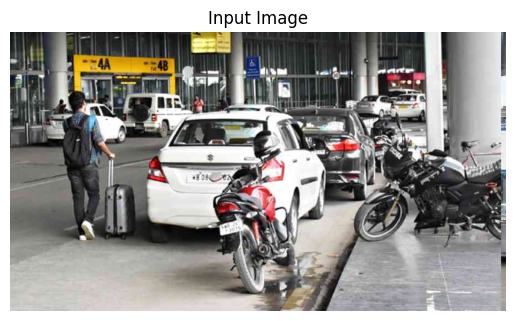


image 1/1 C:\Users\shubh\OneDrive\Desktop\VehicleDetectionProject\vehicles.jpg: 384x640 4 persons, 7 cars, 2 motorcycles, 1 truck, 1 backpack, 2 suitcases, 134.4ms
Speed: 3.7ms preprocess, 134.4ms inference, 4.1ms postprocess per image at shape (1, 3, 384, 640)


AttributeError: 'Results' object has no attribute 'to_pandas'. See valid attributes below.

A class for storing and manipulating inference results.

This class provides comprehensive functionality for handling inference results from various
Ultralytics models, including detection, segmentation, classification, and pose estimation.
It supports visualization, data export, and various coordinate transformations.

Attributes:
    orig_img (np.ndarray): The original image as a numpy array.
    orig_shape (tuple[int, int]): Original image shape in (height, width) format.
    boxes (Boxes | None): Detected bounding boxes.
    masks (Masks | None): Segmentation masks.
    probs (Probs | None): Classification probabilities.
    keypoints (Keypoints | None): Detected keypoints.
    obb (OBB | None): Oriented bounding boxes.
    speed (dict): Dictionary containing inference speed information.
    names (dict): Dictionary mapping class indices to class names.
    path (str): Path to the input imag

In [1]:
# 🚗 Vehicle Detection & Counting using ML (YOLOv5 + PyTorch)

# ==============================
# 1. Install dependencies
# ==============================
!pip install torch torchvision torchaudio --quiet
!pip install opencv-python matplotlib pandas --quiet
!pip install ultralytics --quiet

# ==============================
# 2. Import libraries
# ==============================
import cv2
import torch
import matplotlib.pyplot as plt
import pandas as pd
from ultralytics import YOLO

# ==============================
# 3. Load YOLOv5 pretrained model
# ==============================
# YOLOv5s = small & fast model
print("Loading YOLOv5 model...")
model = YOLO("yolov8s.pt")   # Using YOLOv8 small version (latest)

# ==============================
# 4. Load an image
# ==============================
img_path = "vehicles.jpg"   # <-- Replace with your image file
img = cv2.imread(img_path)

# Convert BGR (OpenCV default) to RGB for plotting
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off")
plt.title("Input Image")
plt.show()

# ==============================
# 5. Run detection
# ==============================
results = model.predict(img_path, conf=0.3)  # confidence threshold = 30%
results[0].show()  # Display with bounding boxes

# ==============================
# 6. Filter only vehicle classes
# ==============================
# COCO dataset class names in YOLO
vehicle_classes = ['car', 'bus', 'truck', 'motorbike']

# Extract detections as pandas dataframe
detections = results[0].to_pandas()
vehicles = detections[detections['name'].isin(vehicle_classes)]

# ==============================
# 7. Print vehicle count
# ==============================
print("===== Vehicle Detection Report =====")
print(f"Total Vehicles Detected: {len(vehicles)}")
print(vehicles[['name', 'confidence']])

# ==============================
# 8. Save output image
# ==============================
results[0].save(filename="detected_output.jpg")
print("✅ Output saved as detected_output.jpg")